# 0. GPU 메모리 확보를 위한 사전 작업

In [1]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import tensorflow as tf

# 메모리 성장 모드 — 필요한 만큼만 점진적으로 할당
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("TF:", tf.__version__)
print("GPU:", gpus)

I0000 00:00:1780028711.035817    2468 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


- GPU를 안전하게 잡아주는 단계
>- `TF_GPU_ALLOCATOR='cuda_malloc_async'`: GPU 메모리 할당을 비동기 모드로 변경. 메모리 단편화를 줄이고 속도가 약간 빨라짐
>- `set_memory_growth(gpu, True)`: 기본 동작은 TensorFlow가 시작하자마자 GPU 메모리를 통째로 점유해버리는데, 이걸 켜면 필요한 만큼만 점진적으로 할당. A100을 여러 학생이 공유할 때 필수

# 1. 모듈 불러오기

In [2]:
# 모듈 불러오기

import os, random
import numpy as np
import tensorflow as tf
import koreanize_matplotlib
import matplotlib.pyplot as plt

# 2. 랜덤시드 고정으로 재현성 확보하기

In [3]:
# 랜덤시드 고정으로 재현성 확보하기
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 3. 이미지 크기와 배치사이즈 설정

In [4]:
# 이미지 크기가 278*278임
IMG_HEIGHT = 278
IMG_WIDTH = 278

BATCH_SIZE = 128 # 하이퍼파라미터 설정시 변경

# 4-1. 데이터 불러오기

In [5]:
# 데이터셋 불러오기
import pandas as pd
path = "/root/data/comnist/"
train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))
print(f"\n데이터 로드 성공! Train: {train.shape}")
print(f"\n데이터 로드 성공! Test: {test.shape}")


데이터 로드 성공! Train: (10260, 2)

데이터 로드 성공! Test: (2565, 1)


- 현업에서는 데이터셋이 거의 항상 이런식으로 제공(csv + 이미지 폴더)

In [6]:
train.head()

,filename,label
0,train/N/58c5a7ea13c33.png,N
1,train/X/58c3f99b763e7.png,X
2,train/Q/59b401384e112.png,Q
3,train/Y/58bf25283cb17.png,Y
4,train/X/58c70784d485a.png,X


In [7]:
test.head()

,filename
0,test/58bed95374e57.png
1,test/58bf1977b67bf.png
2,test/58bc3b7403476.png
3,test/58c3fa2e4df1a.png
4,test/58ac474e1af3b.png


# 4-2. 데이터 경로 설정

In [8]:
# 데이터 경로 설정

TRAIN_DATA_PATH = '/root/data/comnist/images/train/'
TEST_DATA_PATH = '/root/data/comnist/images/test/'

# 4-3-1. 학습 데이터셋 불러오기

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgba" # alpha 채널 정보 포함
)

Found 5616 files belonging to 26 classes.


Using 4493 files for training.


I0000 00:00:1780028749.446525    2468 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1780028749.448975    2468 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79191 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:10:1c.0, compute capability: 8.0


- `image_dataset_from_directory()`: 하위 폴더 이름을 자동으로 클래스 이름으로 인식하게 하는 함수
>- `TRAIN_DATA_PATH`: 하위 폴더를 자동으로 26개의 클래스로 인식
>- `validation_split=0.2`: 20%를 검증용으로 사용. 데이터 로드 시점에 분리한다는 차이
>- `subset='training'`: 80%를 학습용으로 사용. 즉, 5,616장 중 4,493장
>- `seed=SEED`: train / val 분할이 매번 같도록 고정
>- `image_size=(IMG_HEIGHT, IMG_WIDTH)`: 이미지 크기를 자동 리사이즈
>- `color_mode='rgba'`: 보통 RGB(3채널)인데 CoMNIST는 RGBA(4채널)임. 즉, 투명도에 대한 정보를 포함하고 있기때문임. 글씨부분은 불투명(값 = 1)

# 4-3-2. 검증 데이터셋 불러오기

In [10]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="rgba" # alpha 채널 정보 포함
)

Found 5616 files belonging to 26 classes.
Using 1123 files for validation.


# 4-3-3. 데이터 전처리(1)

In [11]:
# 클래스 이름 저장(map 적용 전에)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"클래스 개수: {num_classes}, 라벨: {class_names}")

클래스 개수: 26, 라벨: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


- 전처리 작업 `train_ds.map(...)`으로 변환 함수를 적용하면 `class_names`속성이 사라짐
- 따라서 미리 백업하는 과정
- `num_classes`: 출력층의 뉴런 수로 사용

# 4-3-3. 데이터 전처리(1)

In [12]:
# 투명 배경을 흰색으로 바꾸는 함수 정의
def convert_transparent_to_white_bg_gray(image, label):
    # 정규화 (0~255 -> 0~1)
    image = tf.cast(image, tf.float32) / 255.0

    # 채널 분리
    rgb = image[..., :3]    # 색상 정보 (검은 글씨)
    alpha = image[..., 3:]  # 투명도 정보 (글씨 부분은 1, 배경은 0)

    # 투명한 배경을 흰색(1.0)으로 채우기
    # 결과 = (글씨 색 * 투명도) + (흰색 * (1 - 투명도))
    white_bg = tf.ones_like(rgb)
    new_image = (rgb * alpha) + (white_bg * (1.0 - alpha))

    # RGB -> Grayscale 변환
    # 채널이 3개에서 1개로 줄어듭니다.
    gray_image = tf.image.rgb_to_grayscale(new_image)

    return gray_image, label

- 한장의 이미지를 4단계로 전처리하기
>- 정규화 : 0 ~ 1 범위로 설정
>- RGBA 채널 분리
>>- `image[..., :3]`: 마지막 차원의 0 ~ 2번 -> R, G, B 채널
>>- `image[..., 3:]`: 마지막 차원의 3번 -> 알파채널
>>- `...`은 NumPy 슬라이싱 문법으로 "앞의 모든 차원은 그대로"라는 뜻
>- 투명 배경 -> 흰색합성
>>- `new_image = (rgb * alpha) + (white_bg * (1.0 - alpha))`
>>- 알파 블렌딩
>>>- alpha=1(불투명, 글씨 부분): rgb * 1 + 흰색 * 0 = 원래 색(검정) → 글씨는 그대로
>>>- alpha=0(투명, 배경): rgb * 0 + 흰색 * 1 = 흰색 → 배경은 흰색으로
>>- PNG의 투명 배경을 그대로 모델에 넣으면 RGB값이 (0, 0, 0) 즉, 검은색으로 해석이 되서 글씨와 배경이 똑같이 검정이 됨. 따라서 배경을 흰색으로 변경하는 것임
>- Grayscale 변환
>>- `gray_image = tf.image.rgb_to_grayscale(new_image)`
>>- 3채널 컬러를 1채널 흑백으로. 채널이 3 -> 1로 줄어듬


- "흰 배경 + 검은 글씨를 뒤집어서 검은 배경 + 흰 글씨로 만들기"
- MaxPooling이 큰 값을 가져오기 때문에 흰 배경(= 1.0)이 많으면 쓸모없는 배경이 살아남기 때문임

# 4-3-3. 데이터 전처리(2)

In [13]:
# 데이터셋에 변환 함수 적용
train_ds = train_ds.map(convert_transparent_to_white_bg_gray)
val_ds = val_ds.map(convert_transparent_to_white_bg_gray)

In [14]:
# 성능 최적화
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("데이터 전처리 완료")

데이터 전처리 완료


- `.map()`: 데이터셋의 모든 이미지에 위 함수를 적용하기. 게으른(Lazy) 연산이라 실제 학습 시점에 배치 단위로 처리됨(메모리 절약)
- 성능 최적화 2가지
>- `.cache()`: 첫 epoch에 처리한 데이터를 메모리(또는 디스크)에 캐싱. 따라서 2epoch부터는 디스크 읽기, 전처리 없이 바로 사용 -> 속도 폭증
>- `.prefetch(AUTOTUNE)`: GPU가 학습하는 동안 CPU는 다음 배치를 미리 준비. GPU 노는 시간 감소. `AUTOTUNE`은 TensorFlow가 적절한 버퍼 크기를 자동 선택

# 4-4. 데이터 열어보기

W0000 00:00:1780028769.827029    3153 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


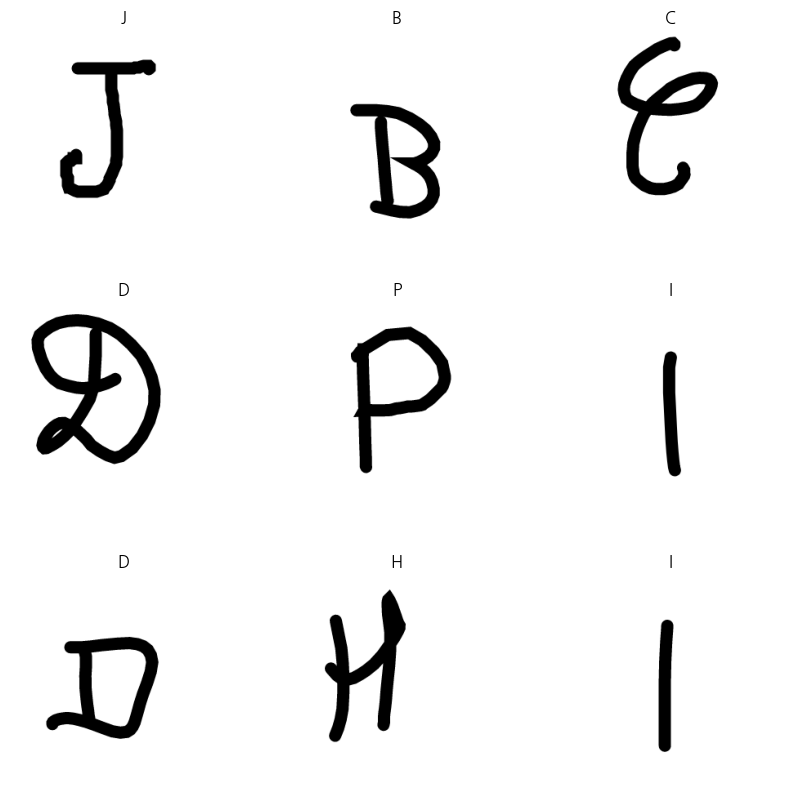

In [15]:
# 학습 데이터셋에서 배치를 하나 가져옵니다
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # 이미지가 정규화(0~1) 되어있으므로 바로 출력 가능
        plt.imshow(images[i].numpy(), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()
    break

- 흰 배경 + 검은 글씨로 잘 처리되었는지 체크
- 라벨이 글씨와 일치하는지 체크
- 회전, 찌그러진 이상한 이미지가 섞여 있지 않은지 체크

# 5. 데이터 증강 설정(Data Augmentation)

In [16]:
data_aug = tf.keras.Sequential([
    # 좌우 반전 (알파벳은 b/d 처럼 의미가 달라질 수 있어 주의 필요, 포트홀엔 필수)
    # tf.keras.layers.RandomFlip("horizontal", seed=SEED),

    # 무작위 회전 (약 20% 범위 내에서 비틀어 보기)
    tf.keras.layers.RandomRotation(0.2, seed=SEED),

    # 무작위 확대/축소 (약 20% 범위 내에서 멀리서/가까이서 보기)
    tf.keras.layers.RandomZoom(0.2, seed=SEED),
])

# 6-1. CNN 구조 설정

In [17]:
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1))

x = data_aug(inputs)

x = tf.keras.layers.Conv2D(32, (3, 3), padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(64, (3, 3), padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.ReLU()(x)

# 출력층 변경: num_classes (알파벳 개수만큼)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="alphabet_cnn_baseline")

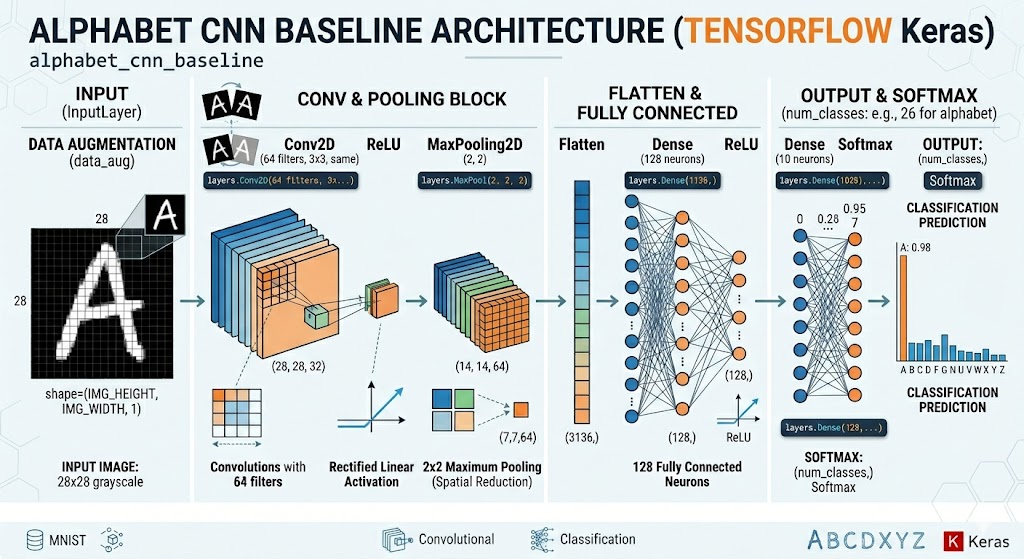

- MNIST_CNN과의 차이 3가지
|차이점|MNIST_CNN|CoMNIST_CNN|
|:---:|:---:|:---:|
|입력크기|(28, 28)|(278, 278, 1)|
|Conv2D 블록|1개에 필터 32개|2개에 필터 64개로 점점 깊어짐|
|출력층 크기|10|26|

# 6-2. CNN 모델 컴파일

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"],
)

# 6-3. CNN 모델 요약

In [19]:
model.summary()

Model: "alphabet_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 278, 278, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 278, 278, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 278, 278, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 278, 278, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 139, 139, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 139, 139, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 139, 139, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 304704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    39,002,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,024,410 (148.87 MB)

 Trainable params: 39,024,410 (148.87 MB)

 Non-trainable params: 0 (0.00 B)

- 파라미터 계산식
>- `Conv2D(32)`
>>- 입력채널 1(흑백), 필터 32개
>>- 필터 1개당 가중치 : 3 * 3 * 1 = 9개
>>- 필터 1개당 편향 : 1개 -> 합 10개
>>- 32개 필터 : 10 * 32 = 320개
>- `Conv2D(64)`
>>- 입력채널 32(앞의 Conv 결과), 필터 64개
>>- 필터 1개당 가중치 : 3 * 3 * 32 = 288개
>>- 필터 1개당 편향 : 1개 -> 합 289개
>>- 32개 필터 : 289 * 64 = 18,496개
>- `MaxPool2D((2, 2))`
>>- `MaxPool2D((2, 2))`은 절반으로 줄임
>>>- 278 / 2 = 139
>>>- 192 / 2 = 69 (소수점 버림)
>>- 따라서 Flatten 직전 모양은 (69, 69, 64). 펼치면 69 * 69 * 64 = 304,704
>- `Dense(128)`
>>- 가중치: 304,704 * 128 = 39,002,112개
>>- 편향: 128개
>>- 합계: 39,002,240개
>- `Dense(26)`
>>- 가중치: 128 * 26 = 3,328개
>>- 편향: 26개
>>- 합계: 3,354개
>- 총 파라미터: 320 + 18,496 + 39,002,240 + 3,354 = 39,024,410

- 만약에 Stride를 키워서 feature map을 더 줄이면 Flatten 결과가 작아져서 Dense 파라미터가 1 / 16으로 줄어듬

# 6-4. Early stopping 설정

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

- "공부를 너무 열심히 해서 답만 외우기 전에, 딱! 멈추기"
>- `monitor='val_loss`: 검증 손실이 감소하지 않으면 멈춰라
>- `patience=5`: val_loss가 5 epoch 연속 개선되지 않으면 학습 종료. 1 ~ 2번 정도는 잠깐의 변동일 수 있어서 여유를 둠
>- `restore_best_weights=True`: 멈출 때 최고 성능이었던 시점의 가중치로 되돌림. 이게 없으면 마지막 epoch(이미 과적합이 시작된)의 가중치를 들고 끝나버림. 따라서 필수


# 7. 학습하기

In [21]:
import time
import datetime

start_time = time.time()

# --- 학습 코드 -------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=[callbacks],
    verbose=1
)
# -------------------------
end_time = time.time()
execution_time = end_time - start_time

# 시:분:초 형태로 자동 변환
str_time = str(datetime.timedelta(seconds=execution_time))
print(f"총 학습 소요 시간: {str_time}")

Epoch 1/30


I0000 00:00:1780028801.083948    2904 cuda_dnn.cc:461] Loaded cuDNN version 92200


36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.0819 - loss: 3.9967 - val_accuracy: 0.1825 - val_loss: 2.5836
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.2949 - loss: 2.2436 - val_accuracy: 0.4274 - val_loss: 1.8745
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.4218 - loss: 1.8282 - val_accuracy: 0.5076 - val_loss: 1.6133
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.5157 - loss: 1.5900 - val_accuracy: 0.5663 - val_loss: 1.4544
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.5858 - loss: 1.3923 - val_accuracy: 0.6073 - val_loss: 1.3495
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6294 - loss: 1.2530 - val_accuracy: 0.6411 - val_loss: 1.2216
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6570 - loss: 1.1750 - val_accuracy: 0.6572 - val_loss: 1.1289
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6679 - loss: 1.1109 - val_accuracy: 0.6465 - val_loss: 

- `callbacks=[callbacks]`: Early Stopping과 연결

# 8. 모델 평가

In [22]:
test_loss, test_acc = model.evaluate(val_ds, verbose=0)
print(f"\n[Test] loss={test_loss:.4f}, acc={test_acc:.4f}")


[Test] loss=0.8078, acc=0.7747


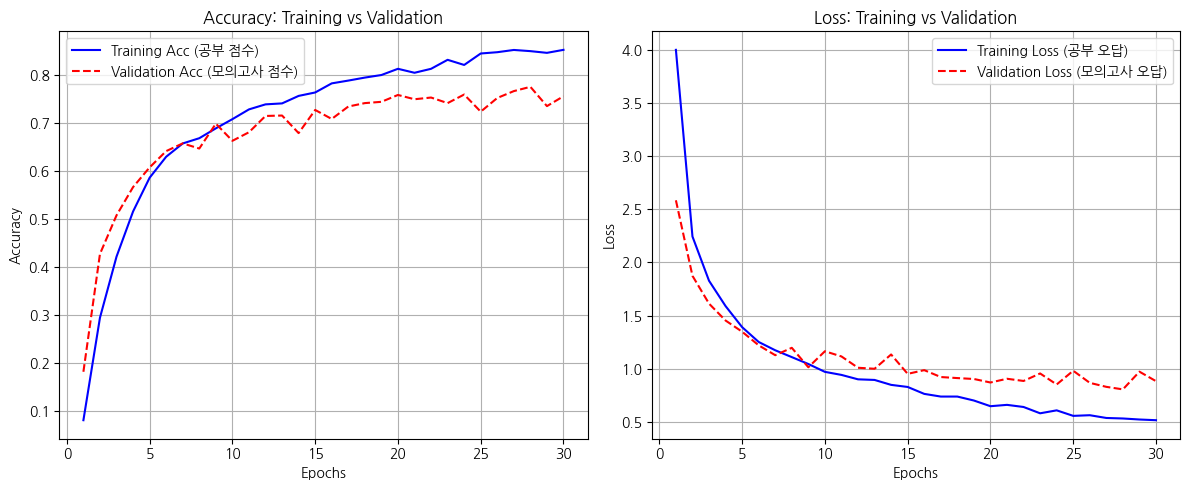

In [23]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # [왼쪽] 정확도(Accuracy) 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Acc (공부 점수)')
    plt.plot(epochs, val_acc, 'r--', label='Validation Acc (모의고사 점수)')
    plt.title('Accuracy: Training vs Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # [오른쪽] 손실(Loss) 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss (공부 오답)')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss (모의고사 오답)')
    plt.title('Loss: Training vs Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 그래프 출력
plot_history(history)

In [24]:
# 테스트 데이터로 예측하기

import pandas as pd
import tensorflow as tf
import os

# 1. 테스트용 전처리 함수 (학습 때와 똑같이)
def load_and_preprocess_test_image(file_path):
    # 이미지 읽기
    img = tf.io.read_file(file_path)
    img = tf.io.decode_png(img, channels=4) # RGBA

    # 크기 조정
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])

    # 투명 배경 처리 (흰색으로)
    img = tf.cast(img, tf.float32) / 255.0
    rgb = img[..., :3]
    alpha = img[..., 3:]
    white_bg = tf.ones_like(rgb)
    new_image = (rgb * alpha) + (white_bg * (1.0 - alpha))

    # 흑백 변환
    gray_image = tf.image.rgb_to_grayscale(new_image)
    return gray_image

# 2. 경로 설정 (사용자 환경에 맞게 수정 필요)
base_path = path

# test.csv 로드
test_df = pd.read_csv(os.path.join(base_path, 'test.csv'))

# 3. 파일 경로 리스트 생성 (순서 보장을 위해 중요!)
# test.csv의 filename에 'test/'가 포함되어 있는지 확인 후 결합
test_file_paths = []
for fname in test_df['filename']:
    # 만약 csv에 'test/img.png'라고 되어있으면 그대로 결합
    full_path = os.path.join(base_path, 'images', fname)
    test_file_paths.append(full_path)

# 4. 데이터셋 생성 (tf.data 활용)
test_ds = tf.data.Dataset.from_tensor_slices(test_file_paths)
test_ds = test_ds.map(load_and_preprocess_test_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print(f"테스트 데이터셋 준비 완료! 총 {len(test_file_paths)}개")

# 5. 예측 수행
print("예측을 시작합니다... (잠시만 기다려주세요)")
predictions = model.predict(test_ds)

# 6. 결과 변환 (확률 -> 클래스 라벨)
predicted_indices = np.argmax(predictions, axis=1)
predicted_labels = [class_names[i] for i in predicted_indices]

# 7. submission.csv 저장
submission = pd.DataFrame({
    'filename': test_df['filename'],
    'label': predicted_labels
})

submission.to_csv('submission.csv', index=False)
print("✅ submission.csv 파일 생성이 완료되었습니다!")
print(submission.head())

테스트 데이터셋 준비 완료! 총 2565개
예측을 시작합니다... (잠시만 기다려주세요)
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
✅ submission.csv 파일 생성이 완료되었습니다!
                 filename label
0  test/58bed95374e57.png     J
1  test/58bf1977b67bf.png     J
2  test/58bc3b7403476.png     P
3  test/58c3fa2e4df1a.png     A
4  test/58ac474e1af3b.png     H


- 캐글 제출 파일 생성
- 함수가 필요한 이유
>- 학습 데이터는 `image_dataset_from_directory`가 폴더 구조로 알아서 처리했지만, 테스트 데이터는 라벨이 없고 csv의 순서대로 예측해야 함. 그래서 한 장씩 직접 읽어서 처리하는 함수가 필요
- 단계별 흐름
>- 전처리 함수: 학습 때 적용한 변환을 그대로 재현. 이게 어긋나면 예측이 완전히 망가짐
>- `test_df['filename']`순서대로 경로 만들기: 순서 보장이 매우 중요. 캐글은 test.csv의 행 순서와 제출 파일의 행 순서가 일치한다고 가정
>- `tf.data.Dataset.from_tensor_slices`: 경로 리스트를 데이터셋으로 변환 -> `.map`으로 이미지 로드 + 전처리 -> `.batch` -> `.prefetch`
>- `model.predict(test_ds)`: 결과는 (N, 26) 향태의 확률 배열. 각 행이 한 이미지의 26개 클래스 확률
>- `np.argmax(predictions, axis=1)`: 각 행에서 가장 확률이 높은 인덱스 추출(0 ~ 25 정수)
>- class_names[i]: 인덱스를 'A' ~ 'Z' 문자로 변환
>- submission.csv: filename, label 두 컬럼으로 저장